In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [3]:
from google.colab import files
uploaded = files.upload()

Saving adult_with_headers (1).csv to adult_with_headers (1).csv


In [6]:
df = pd.read_csv("adult_with_headers (1).csv")

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


## Data Exploration

The Adult dataset contains demographic and income-related information.
Basic exploration helps identify missing values, data types, and feature distributions.

In [10]:
df.replace(' ?', np.nan, inplace=True)

df.dropna(inplace=True)

## Missing Value Handling

Missing values were replaced with NaN and removed to improve data quality.

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')
Categorical Columns: Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


In [12]:
scaler_standard = StandardScaler()

df_standard = df.copy()

df_standard[num_cols] = scaler_standard.fit_transform(df[num_cols])

df_standard.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.042796,State-gov,-1.062722,Bachelors,1.128918,Never-married,Adm-clerical,Not-in-family,White,Male,0.146092,-0.218586,-0.077734,United-States,<=50K
1,0.880288,Self-emp-not-inc,-1.007871,Bachelors,1.128918,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.147445,-0.218586,-2.331531,United-States,<=50K
2,-0.033340,Private,0.244693,HS-grad,-0.439738,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.147445,-0.218586,-0.077734,United-States,<=50K
3,1.108695,Private,0.425240,11th,-1.224066,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.147445,-0.218586,-0.077734,United-States,<=50K
4,-0.794697,Private,1.406658,Bachelors,1.128918,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.147445,-0.218586,-0.077734,Cuba,<=50K


## Standard Scaling

Standard Scaling transforms data to have mean 0 and standard deviation 1.
It is preferred when data follows a normal distribution.

In [13]:
scaler_minmax = MinMaxScaler()

df_minmax = df.copy()

df_minmax[num_cols] = scaler_minmax.fit_transform(df[num_cols])

df_minmax.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.301370,State-gov,0.043338,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,United-States,<=50K
1,0.452055,Self-emp-not-inc,0.047277,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,United-States,<=50K
2,0.287671,Private,0.137244,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,United-States,<=50K
3,0.493151,Private,0.150212,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,United-States,<=50K
4,0.150685,Private,0.220703,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,Cuba,<=50K


## Min-Max Scaling

Min-Max Scaling converts values between 0 and 1.
It is useful for distance-based algorithms and neural networks.

In [14]:
small_cat_cols = [col for col in cat_cols if df[col].nunique() < 5]

df_onehot = pd.get_dummies(df, columns=small_cat_cols)

df_onehot.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,2174,0,40,United-States,False,True,True,False
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,0,0,13,United-States,False,True,True,False
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,0,0,40,United-States,False,True,True,False
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,40,United-States,False,True,True,False
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,40,Cuba,True,False,True,False


## One-Hot Encoding

One-Hot Encoding creates separate columns for categories.
It avoids introducing ordinal relationships.

In [15]:
large_cat_cols = [col for col in cat_cols if df[col].nunique() >= 5]

le = LabelEncoder()

for col in large_cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,5,77516,9,13,4,0,1,4,Male,2174,0,40,38,<=50K
1,50,4,83311,9,13,2,3,0,4,Male,0,0,13,38,<=50K
2,38,2,215646,11,9,0,5,1,4,Male,0,0,40,38,<=50K
3,53,2,234721,1,7,2,5,0,2,Male,0,0,40,38,<=50K
4,28,2,338409,9,13,2,9,5,2,Female,0,0,40,4,<=50K


## Label Encoding

Label Encoding converts categories into numerical labels.
It is memory efficient but may introduce ordinal relationships.

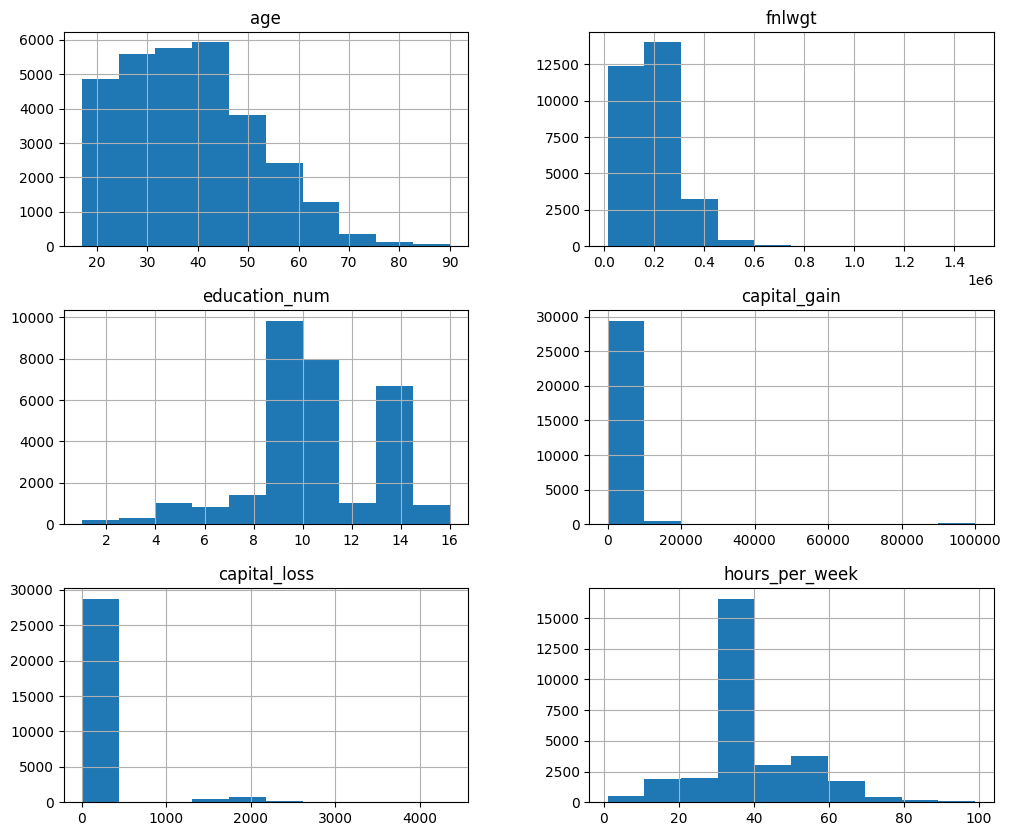

In [16]:
df[num_cols].hist(figsize=(12,10))

plt.show()

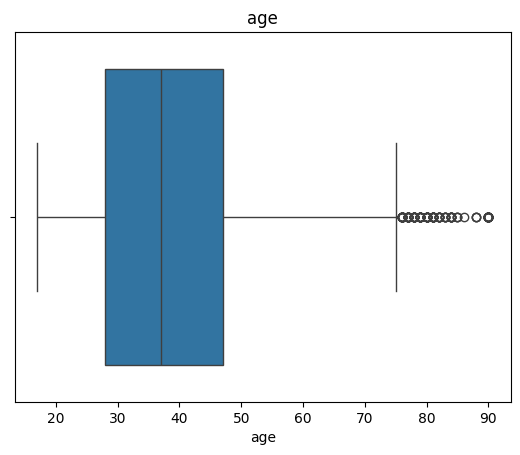

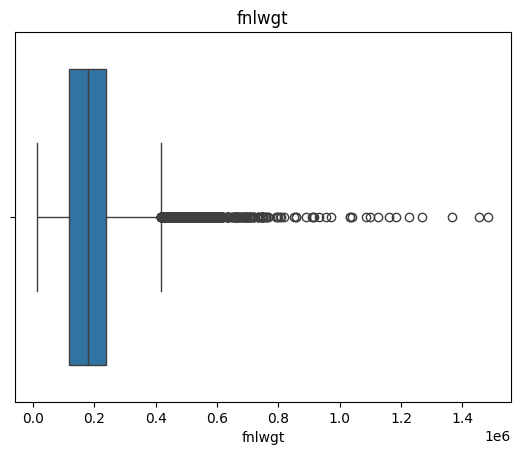

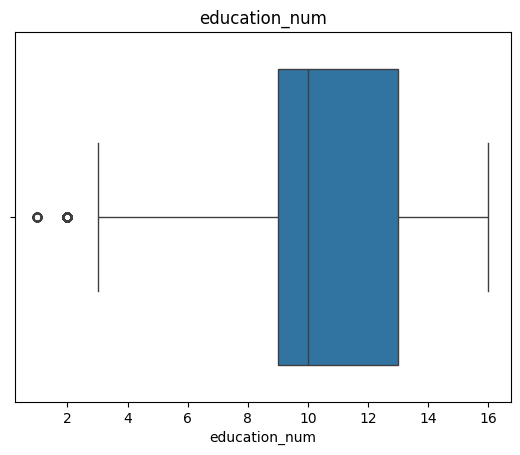

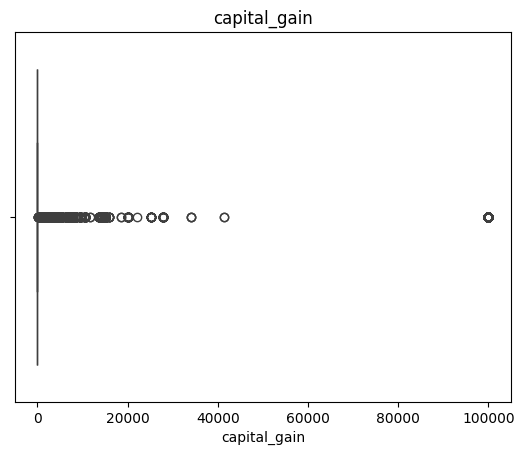

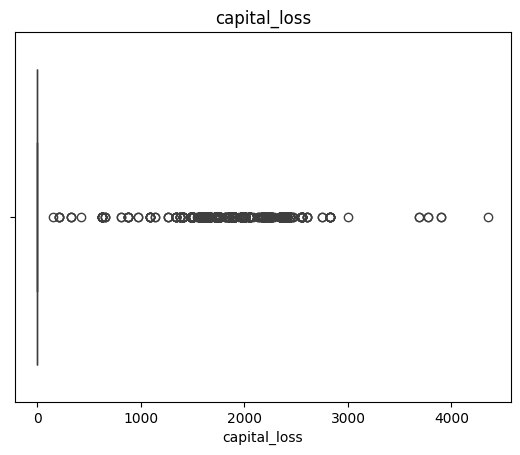

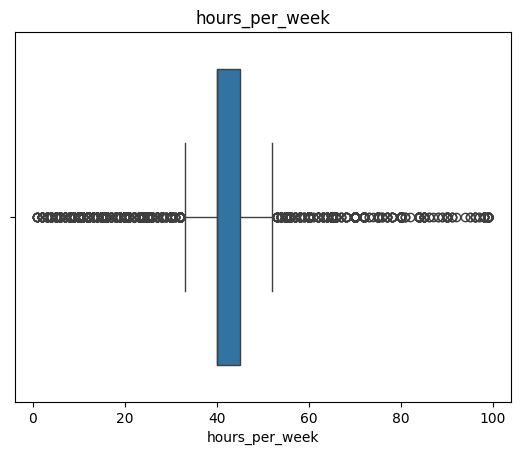

In [17]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

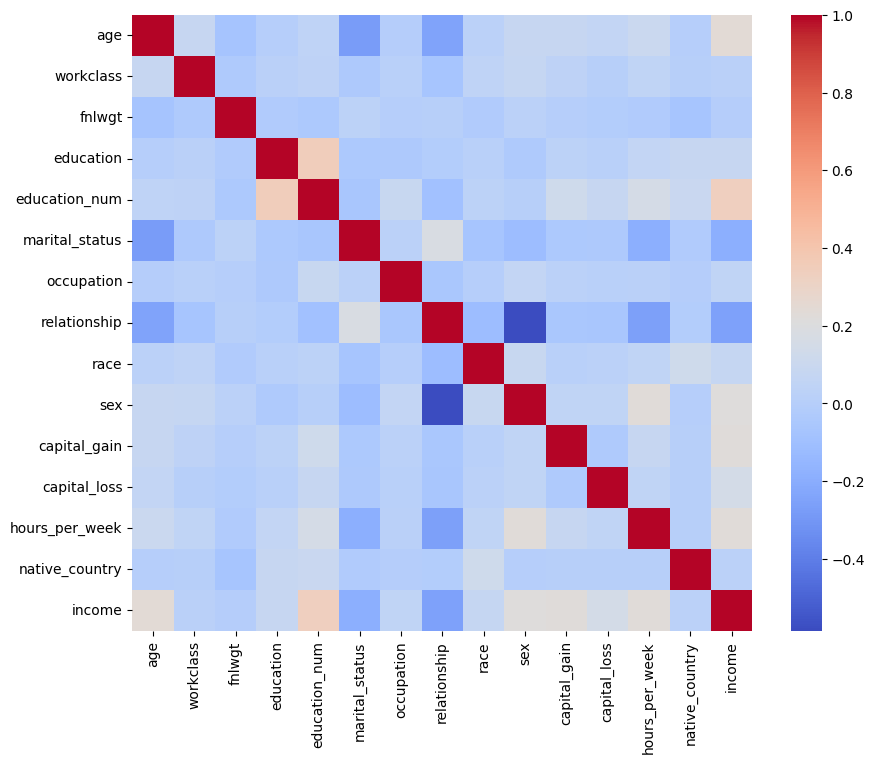

In [19]:
plt.figure(figsize=(10,8))

# Ensure all categorical columns in df are numerical before calculating correlation
# The 'sex' and 'income' columns are still strings in df, as they were part of small_cat_cols
# and only df_onehot was created using one-hot encoding for them.
# To use df for correlation, we need to label encode them as well.
le = LabelEncoder()
if 'sex' in df.columns:
    df['sex'] = le.fit_transform(df['sex'])
if 'income' in df.columns:
    df['income'] = le.fit_transform(df['income'])

sns.heatmap(df.corr(), annot=False, cmap='coolwarm')

plt.show()

## Correlation Analysis

Heatmap helps identify relationships between numerical variables.
Strong correlations indicate important features.

In [21]:
df['capital_total'] = df['capital_gain'] + df['capital_loss']

df['hours_per_age'] = df['hours_per_week'] / df['age']

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_total,hours_per_age
0,39,5,77516,9,13,4,0,1,4,1,2174,0,40,38,0,2174,1.025641
1,50,4,83311,9,13,2,3,0,4,1,0,0,13,38,0,0,0.260000
2,38,2,215646,11,9,0,5,1,4,1,0,0,40,38,0,0,1.052632
3,53,2,234721,1,7,2,5,0,2,1,0,0,40,38,0,0,0.754717
4,28,2,338409,9,13,2,9,5,2,0,0,0,40,4,0,0,1.428571


## Feature Engineering

New features were created to improve model performance.

- capital_total combines gain and loss.
- hours_per_age represents work intensity relative to age.

In [22]:
df['log_age'] = np.log1p(df['age'])

df[['age', 'log_age']].head()

,age,log_age
0,39,3.688879
1,50,3.931826
2,38,3.663562
3,53,3.988984
4,28,3.367296


## Log Transformation

Log transformation reduces skewness and normalizes the distribution.

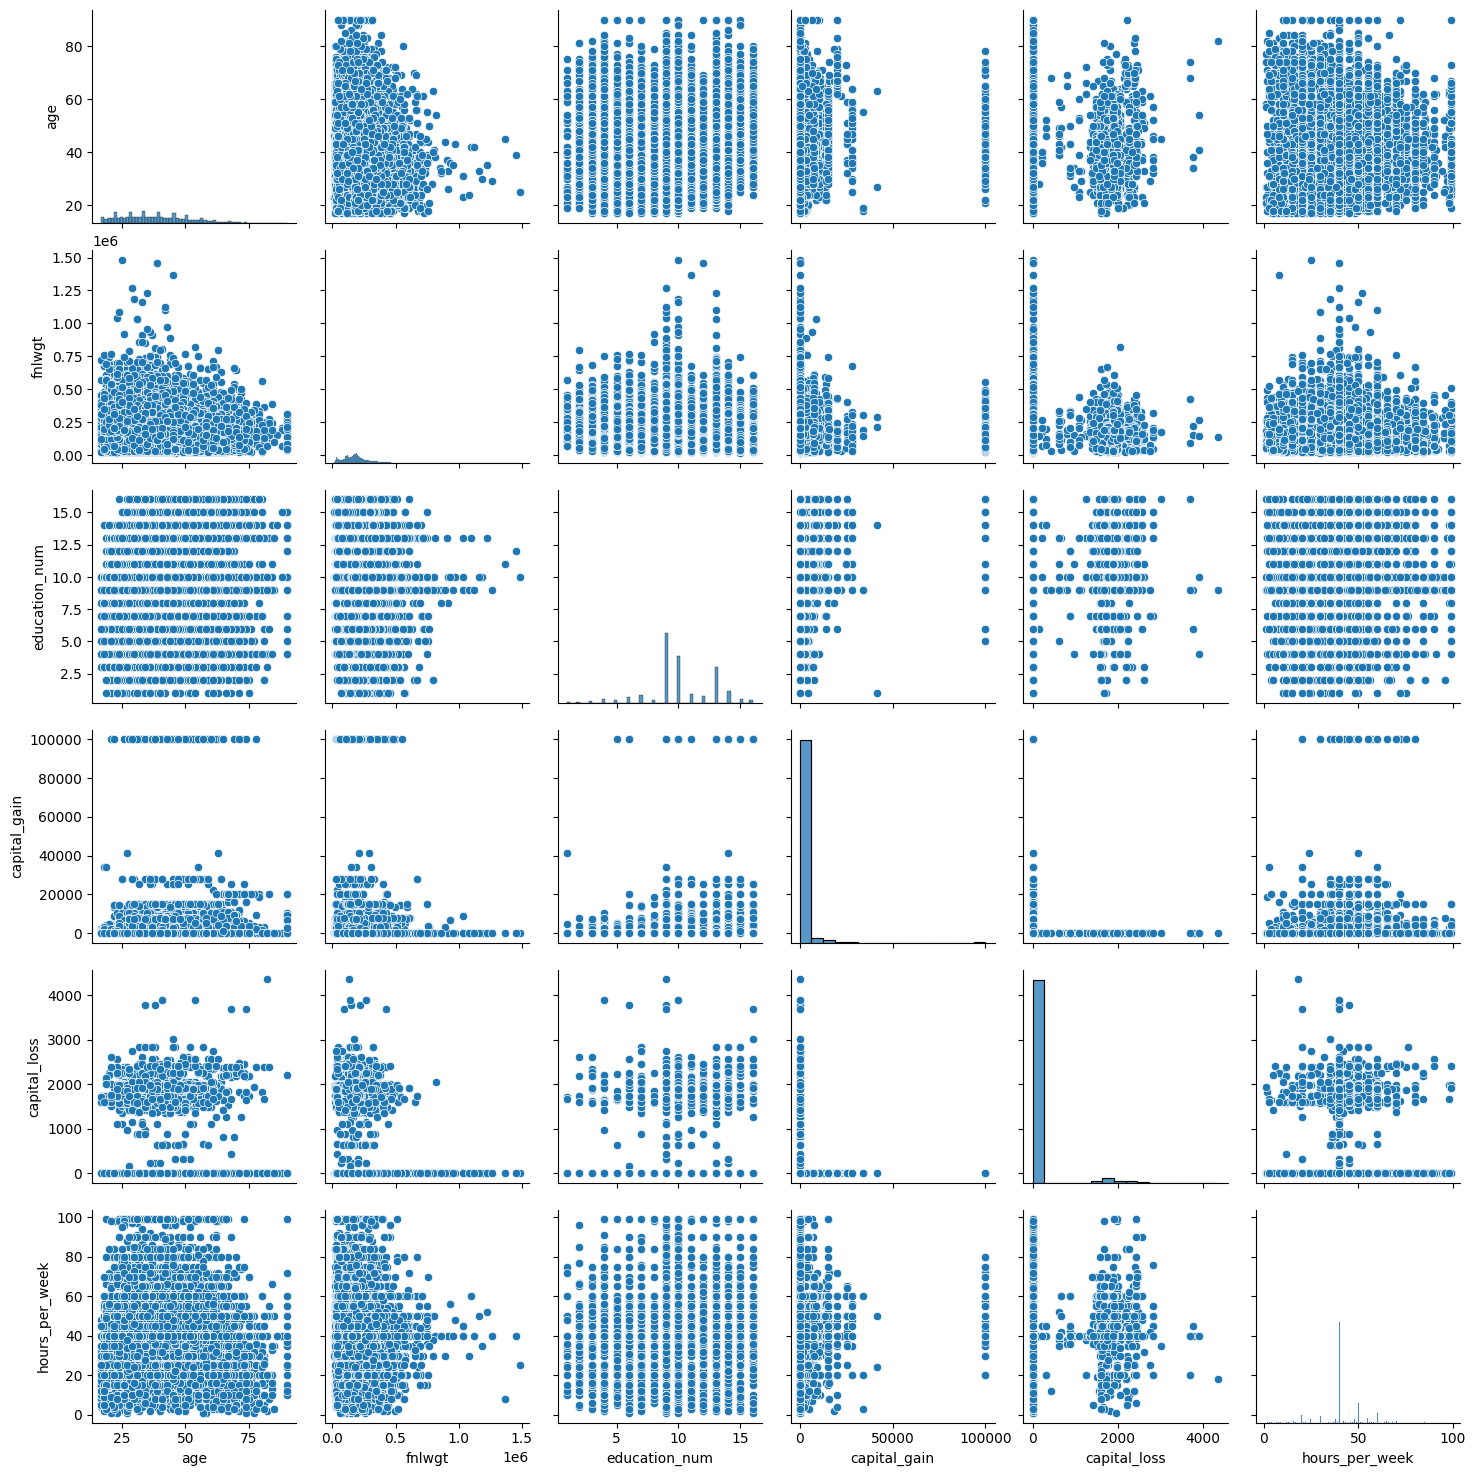

In [24]:
sns.pairplot(df[num_cols])

plt.show()

## Conclusion

Data preprocessing and feature engineering techniques were applied successfully.

Missing values were handled, scaling techniques were used, and categorical variables were encoded.

Feature engineering improved data representation and prepared the dataset for machine learning tasks.

##INTERVIEW QUESTIONS

### One-Hot Encoding
- Avoids ordinal relationships
- Increases dimensionality

### Label Encoding
- Memory efficient
- May introduce false ordering

### Standard Scaling
- Mean = 0
- Std Dev = 1
- Good for normally distributed data

### Min-Max Scaling
- Scales between 0 and 1
- Good for neural networks